In [1]:
# =====================================================================
# Adım 1: IMPORTS + SAFE DATA LOADING
# =====================================================================
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import f1_score, classification_report, roc_auc_score
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings("ignore")

file_path = None
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        if filename.endswith('.csv'):
            file_path = os.path.join(dirname, filename)

if file_path is None:
    raise FileNotFoundError("CSV dosyası bulunamadı. Lütfen dataseti ekleyin!")

df = pd.read_csv(file_path)
print("Veri seti başarıyla yüklendi! Shape:", df.shape)
df.head()

Veri seti başarıyla yüklendi! Shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [2]:
# =====================================================================
# Adım 2: DATA QUALITY ASSESSMENT (Veri Kalitesi)
# =====================================================================
print("Eksik Değer Kontrolü:\n", df.isnull().sum().sum())
print("Kopya Satır Sayısı:", df.duplicated().sum())

# Gereksiz sütunları çıkaralım
drop_cols = ["EmployeeCount", "Over18", "StandardHours", "EmployeeNumber"]
df = df.drop(columns=drop_cols, errors="ignore")
df['Attrition'] = df['Attrition'].astype(str).str.strip()

print("Yeni Shape:", df.shape)
df.info()

Eksik Değer Kontrolü:
 0
Kopya Satır Sayısı: 0
Yeni Shape: (1470, 31)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole 

In [9]:
# =====================================================================
# Adım 3: FEATURE ENGINEERING (Özellik Mühendisliği)
# =====================================================================
df["TotalSatisfaction"] = (
    df["JobSatisfaction"].fillna(0) +
    df["EnvironmentSatisfaction"].fillna(0) +
    df["RelationshipSatisfaction"].fillna(0) +
    df["WorkLifeBalance"].fillna(0)
)

df["IncomePerYear"] = df["MonthlyIncome"] * 12
df["YearsPerAge"] = df["TotalWorkingYears"] / (df["Age"] + 1)
df["TenureRatio"] = df["YearsAtCompany"] / (df["TotalWorkingYears"] + 1)

print("Yeni özellikler eklendi. Sütun Sayısı:", df.shape[1])
df.head()

Yeni özellikler eklendi. Sütun Sayısı: 35


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,TotalSatisfaction,IncomePerYear,YearsPerAge,TenureRatio
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,2,Female,...,0,1,6,4,0,5,8,71916,0.190476,0.666667
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,3,Male,...,3,3,10,7,1,7,12,61560,0.200000,0.909091
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,4,Male,...,3,3,0,0,0,0,12,25080,0.184211,0.000000
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,4,Female,...,3,3,8,7,3,0,13,34908,0.235294,0.888889
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,Male,...,3,3,2,2,2,2,10,41616,0.214286,0.285714


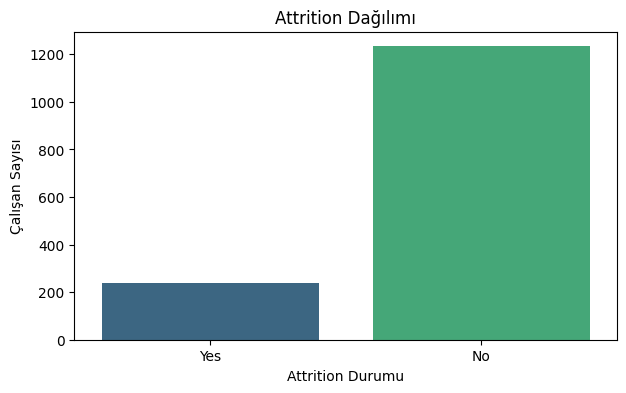

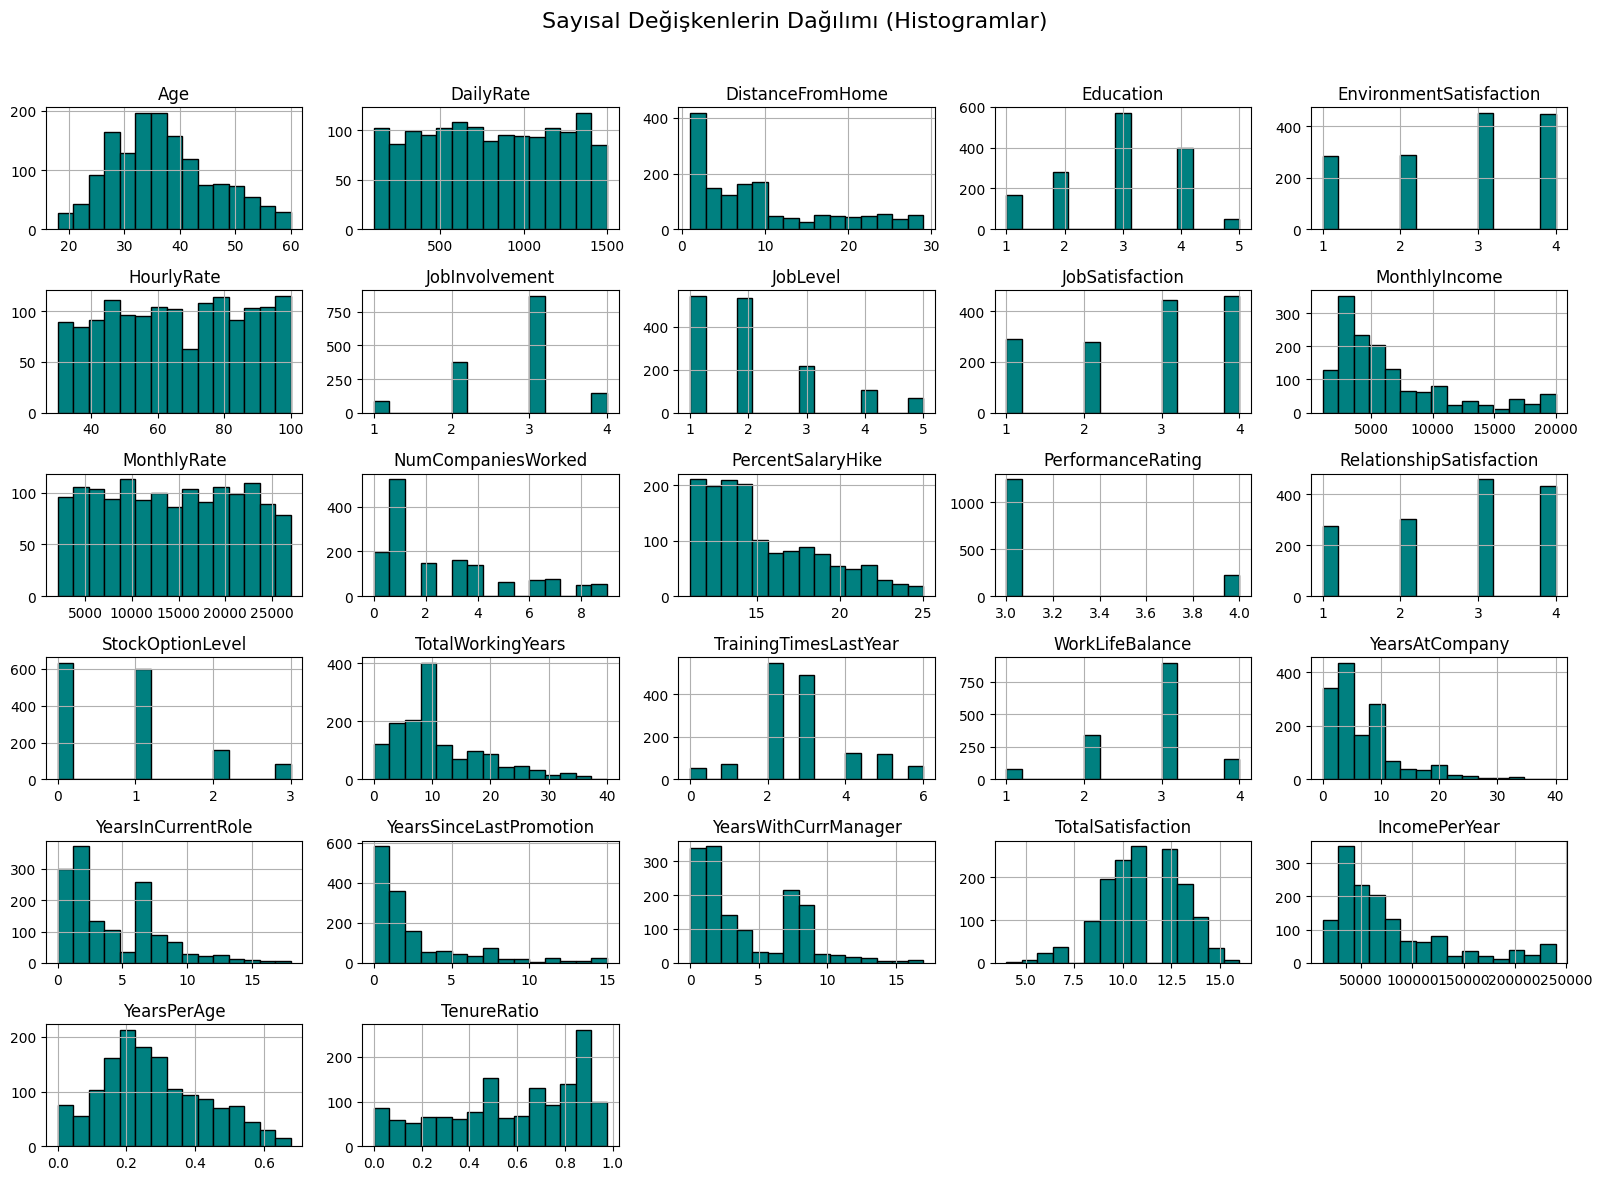

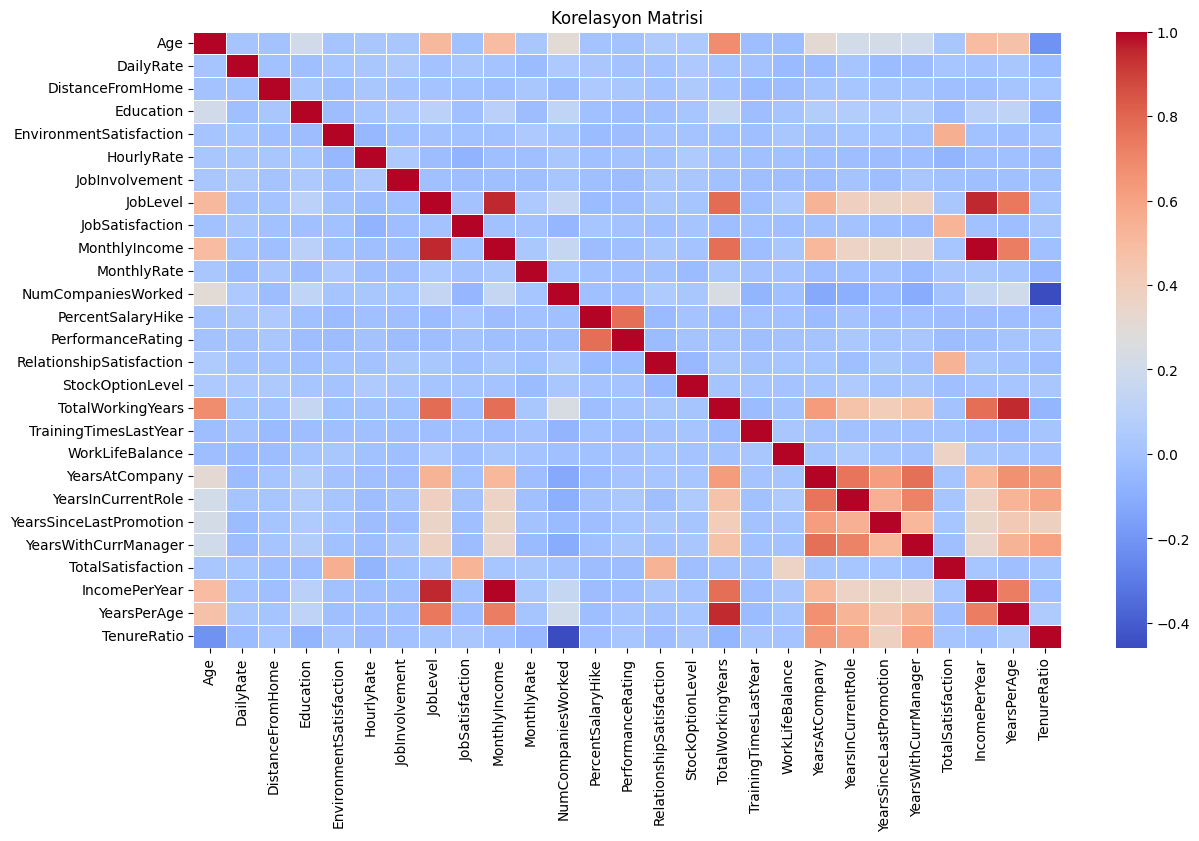

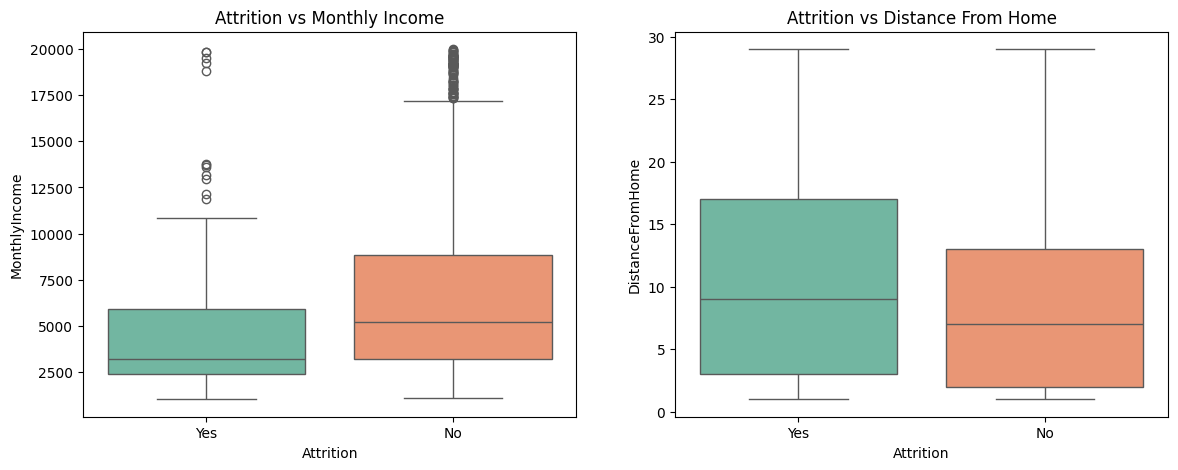

In [11]:
# =====================================================================
# Adım 4: EDA & GÖRSELLEŞTİRME (Sunum ve Rapor İçin)
# =====================================================================

# Hedef Değişken Dağılımı
plt.figure(figsize=(7, 4))
sns.countplot(x="Attrition", data=df, palette="viridis")
plt.title("Attrition Dağılımı")
plt.xlabel("Attrition Durumu")
plt.ylabel("Çalışan Sayısı")
plt.show()

# Sayısal Değişkenlerin Histogramları
df.hist(bins=15, figsize=(16, 12), color='teal', edgecolor='black')
plt.suptitle("Sayısal Değişkenlerin Dağılımı (Histogramlar)", fontsize=16)
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

# Korelasyon Matrisi
plt.figure(figsize=(14, 8))
sns.heatmap(df.corr(numeric_only=True), cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Korelasyon Matrisi")
plt.show()

# Kutu Grafikleri
income_data = df[['Attrition', 'MonthlyIncome']].dropna()
distance_data = df[['Attrition', 'DistanceFromHome']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x="Attrition", y="MonthlyIncome", data=income_data, hue="Attrition", legend=False, ax=axes[0], palette="Set2")
axes[0].set_title("Attrition vs Monthly Income")

sns.boxplot(x="Attrition", y="DistanceFromHome", data=distance_data, hue="Attrition", legend=False, ax=axes[1], palette="Set2")
axes[1].set_title("Attrition vs Distance From Home")
plt.show()

In [12]:
# =====================================================================
# Adım 5: X VE Y AYIRIMI VE TRAIN-TEST SPLIT (Stratified)
# =====================================================================
X = df.drop("Attrition", axis=1)
y = df["Attrition"].map({"Yes": 1, "No": 0})

valid_idx = y.dropna().index
X = X.loc[valid_idx]
y = y.loc[valid_idx]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

print("Eğitim seti boyutu (X_train):", X_train.shape)

Eğitim seti boyutu (X_train): (1176, 34)


In [16]:
# =====================================================================
# Adım 6: PREPROCESSOR VE PIPELINE OLUŞTURMA
# =====================================================================
cat_cols = X.select_dtypes(include="object").columns
num_cols = X.select_dtypes(exclude="object").columns

preprocessor = ColumnTransformer([
    ("num", Pipeline([("scaler", StandardScaler())]), num_cols),
    ("cat", Pipeline([("onehot", OneHotEncoder(handle_unknown="ignore"))]), cat_cols)
])

In [17]:
# =====================================================================
# Adım 7: MODEL EĞİTİMİ (XGBoost Classifier ile Güçlü F1-Score)
# =====================================================================
# Dengesiz veri setini dengelemek için ağırlıklandırma katsayısı
scale_pos_weight = (y_train == 0).sum() / (y_train == 1).sum()

xgb = Pipeline([
    ("preprocessor", preprocessor),
    ("model", XGBClassifier(
        n_estimators=700,        # Ağaç sayısını artırarak modeli güçlendirdik
        max_depth=5,             # Overfitting'i önlemek için derinliği dengeledik
        learning_rate=0.02,      # Öğrenme hızını düşürerek genelleme yeteneğini artırdık
        subsample=0.8,           # Alt örnekleme
        colsample_bytree=0.8,    # Sütun örnekleme
        scale_pos_weight=scale_pos_weight,
        random_state=42,
        eval_metric="logloss"
    ))
])

print("Model eğitiliyor...")
xgb.fit(X_train, y_train)
print("Model başarıyla eğitildi.")

Model eğitiliyor...
Model başarıyla eğitildi.


In [18]:
# =====================================================================
# Adım 8: MODEL PERFORMANSI VE METRİKLERİ
# =====================================================================
y_pred = xgb.predict(X_test)

print("\n--- SINIFLANDIRMA RAPORU ---")
print(classification_report(y_test, y_pred))

f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1])

print(f"Test F1-Score : {f1:.4f}")
print(f"Test ROC-AUC  : {roc_auc:.4f}")

# Çapraz Doğrulama (Stratified K-Fold - Proposal form ile uyumlu)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_scores = cross_val_score(xgb, X, y, cv=cv, scoring="f1")

print("\n--- CROSS-VALIDATION SONUÇLARI ---")
print("CV F1 Skorları:", cv_scores)
print(f"Ortalama CV F1-Score: {cv_scores.mean():.4f}")


--- SINIFLANDIRMA RAPORU ---
              precision    recall  f1-score   support

           0       0.88      0.94      0.91       247
           1       0.50      0.32      0.39        47

    accuracy                           0.84       294
   macro avg       0.69      0.63      0.65       294
weighted avg       0.82      0.84      0.83       294

Test F1-Score : 0.3896
Test ROC-AUC  : 0.7706

--- CROSS-VALIDATION SONUÇLARI ---
CV F1 Skorları: [0.46153846 0.46666667 0.52631579 0.54054054 0.50632911]
Ortalama CV F1-Score: 0.5003


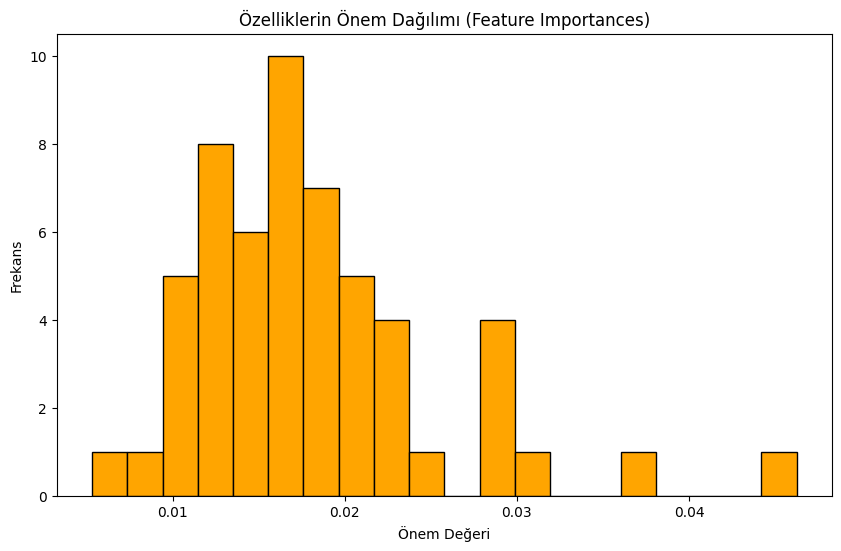

In [19]:
# =====================================================================
# Adım 9: FEATURE IMPORTANCE (Önem Dağılımı Görseli)
# =====================================================================
model = xgb.named_steps["model"]
importances = model.feature_importances_

plt.figure(figsize=(10, 6))
plt.hist(importances, bins=20, color="orange", edgecolor="black")
plt.title("Özelliklerin Önem Dağılımı (Feature Importances)")
plt.xlabel("Önem Değeri")
plt.ylabel("Frekans")
plt.show()